In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
import torch
from datasets import load_dataset
from transformers import DataCollatorForTokenClassification
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from stopwatch import Stopwatch
from torch.optim import AdamW
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu" 
print(device)

cuda


In [3]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B", device_map=device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

## Question 2.1

In [4]:
r16_config = LoraConfig(
                r                       = 16,
                lora_alpha              = 16,
                lora_dropout            = 0.0,
                target_modules          = "all-linear",
                bias                    = "none",
                task_type               = "CAUSAL_LM",
            )

In [5]:
model_16r = get_peft_model(model, r16_config)

In [6]:
model_16r.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [7]:
del model_16r
del model

# Question 2.2

In [8]:
BATCH_SIZE = 1
EPOCHS = 5
LR = 0.0001

In [9]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")

In [10]:
train = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_sft").select(range(1001)) # have an extra example bc one instance won't have any assistant text with
print(f"Train Dataset Length: {len(train)}")

test = load_dataset("HuggingFaceH4/ultrachat_200k", split="test_sft").select(range(2500))
print(f"Test Dataset Length: {len(test)}")

print(train[0])

Train Dataset Length: 1001
Test Dataset Length: 2500
{'prompt': "These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?\nOn your Collections pages & Featured Collections sections, you can easily show the secondary image of a product on hover by enabling one of the theme's built-in settings!\nYour Collection pages & Featured Collections sections will now display the secondary product image just by hovering over that product image thumbnail.\nDoes this feature apply to all sections of the theme or just specific ones as listed in the text material?", 'prompt_id': 'f0e37e9f7800261167ce91143f98f511f768847236f133f2d0aed60b444ebe57', 'messages': [{'content': "These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?\nOn your Collections pages & Featured Collections sections, you can easily show the second

In [11]:
special_tokens = ["<|im_start|>", "user", "<|im_end|>", "assistant", "\n", "system"]

for token in special_tokens:
    print(f"Token {token}: ID: {tokenizer.encode(token)}")

Token <|im_start|>: ID: [151644]
Token user: ID: [872]
Token <|im_end|>: ID: [151645]
Token assistant: ID: [77091]
Token 
: ID: [198]
Token system: ID: [8948]


In [12]:
ASSISTANT_START = [151644, 77091, 198]
END = 151645

In [13]:
def tokenize(example):
    tokenized = tokenizer.apply_chat_template(example['messages'], tokenize=True, return_dict=True, add_generation_prompt=False, truncation=True, max_length=2048)

    # only train on assistant text
    labels = []
    i = 0
    recording = False
    while i < len(tokenized['input_ids']):
        if tokenized['input_ids'][i:i+3] == ASSISTANT_START:
            recording = True
            i += 3
            labels.extend([-100, -100, -100])
            continue

        if recording:
            labels.append(tokenized['input_ids'][i])
        else:
            labels.append(-100)

        if tokenized['input_ids'][i] == END:
            recording = False

        i += 1

    assert len(labels) == len(tokenized['input_ids'])
    tokenized['labels'] = labels

    return tokenized

In [14]:
# make sure we have some assistant text to train on
train = train.map(tokenize, batched = False, remove_columns=train.column_names).filter(lambda x: any(label != -100 for label in x["labels"]))
test = test.map(tokenize, batched = False, remove_columns=test.column_names).filter(lambda x: any(label != -100 for label in x["labels"]))

coallator = DataCollatorForTokenClassification(tokenizer = tokenizer, padding = True, return_tensors = "pt", label_pad_token_id=-100)

train_loader = DataLoader(train , batch_size = BATCH_SIZE, shuffle = True, collate_fn = coallator)
test_loader =  DataLoader(test, batch_size = BATCH_SIZE, shuffle = False, collate_fn = coallator)


In [15]:
def epoch(train_set, model, optimizer):
    model.train()
    batch_loss = []
    
    for batch in tqdm(train_set, desc="Train Batch: ", leave=False, position=1):
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        optimizer.zero_grad()
                    
        loss = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels = batch["labels"]).loss

        if not torch.isfinite(loss):
            print("Got bad loss, exiting")
            print(f"Tokens: {batch['input_ids']}")
            print(f"Labels: {batch['labels']}")
            break
        
        loss.backward()
        optimizer.step()

        batch_loss.append(loss.item())

    return batch_loss


@torch.no_grad()
def evaluate(test_set, model):
    model.eval()
    batch_loss = []

    for batch in tqdm(test_set, desc="Test Batch: ", leave=False, position=1):
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

        loss = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels = batch["labels"]).loss

        batch_loss.append(loss.item())
        
    return batch_loss


def train_loop(train_set, test_set, model, optimizer, epochs):
    timer = Stopwatch()
    timer.reset()
    torch.cuda.reset_peak_memory_stats()

    train_loss_hist = []
    test_loss_hist = []

    for _ in tqdm(range(epochs), desc="Epoch: ", leave=True, position=0):
        torch.cuda.synchronize()
        timer.start()

        train_loss = epoch(train_set, model, optimizer)

        torch.cuda.synchronize()
        timer.stop()

        test_loss = evaluate(test_set, model)

        train_loss_hist.append(sum(train_loss)/len(train_loss))
        test_loss_hist.append(sum(test_loss)/len(test_loss))

    peak_allocated = torch.cuda.max_memory_allocated() / 1024**3
    print(f"Peak allocated GPU memory: {peak_allocated:.4f} GB")

    print(f"Training time: {timer.duration:.4f} seconds")

    return train_loss_hist, test_loss_hist

### Full Fine Tune

In [16]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B", device_map=device)
optimizer = AdamW(params=[param for param in model.parameters() if param.requires_grad], lr=LR)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [17]:
train_loss_hist, test_loss_hist = train_loop(train_loader, test_loader, model, optimizer, EPOCHS)
torch.save(model.state_dict(), "full_ft.pt")

Epoch: 100%|██████████| 5/5 [09:46<00:00, 117.23s/it]


Peak allocated GPU memory: 8.9847 GB
Training time: 347.8456 seconds


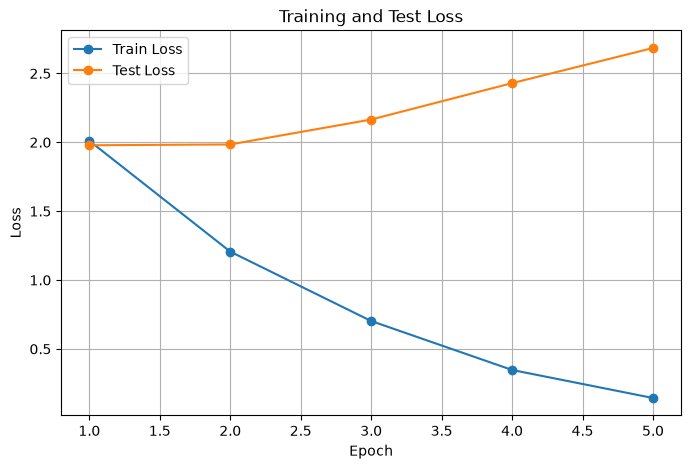

In [23]:
epochs = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss_hist, marker="o", label="Train Loss")
plt.plot(epochs, test_loss_hist, marker="o", label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)

plt.show()

### LoRA R=1

In [20]:
r16_config = LoraConfig(
                r                       = 16,
                lora_alpha              = 16,
                lora_dropout            = 0.0,
                target_modules          = "all-linear",
                bias                    = "none",
                task_type               = "CAUSAL_LM",
            )

In [21]:
import shutil

print("gcc:", shutil.which("gcc"))
print("clang:", shutil.which("clang"))
print("cl:", shutil.which("cl"))

gcc: /usr/bin/gcc
clang: None
cl: None


### LoRA R=4

### LoRA R=16